In [1]:
import pandas as pd

In [2]:
# Load the dataset
dataset_path = 'data/ddidiversedermatologyimages/ddi_metadata.csv'
ddi_df = pd.read_csv(dataset_path)

ddi_df

,Unnamed: 0,DDI_ID,DDI_file,skin_tone,malignant,disease
0,0,1,000001.png,56,True,melanoma-in-situ
1,1,2,000002.png,56,True,melanoma-in-situ
2,2,3,000003.png,56,True,mycosis-fungoides
3,3,4,000004.png,56,True,squamous-cell-carcinoma-in-situ
4,4,5,000005.png,12,True,basal-cell-carcinoma
...,...,...,...,...,...,...
651,651,652,000652.png,34,False,pyogenic-granuloma
652,652,653,000653.png,34,False,melanocytic-nevi
653,653,654,000654.png,34,False,acral-melanotic-macule
654,654,655,000655.png,34,True,squamous-cell-carcinoma


total number of samples: 656
mean samples per disease: 8.41
disease with most samples: 'melanocytic-nevi' with 119 samples
disease with least samples: 'subcutaneous-t-cell-lymphoma' with 1 samples

quartile values for disease counts:
q1 (25th percentile): 1.0
q2 (median/50th percentile): 2.0
q3 (75th percentile): 6.0

number of diseases per quartile:
diseases with <= q1 samples (1): 30
diseases with > q1 and <= q2 samples (1-2): 11
diseases with > q2 and <= q3 samples (2-6): 18
diseases with > q3 samples (6+): 19


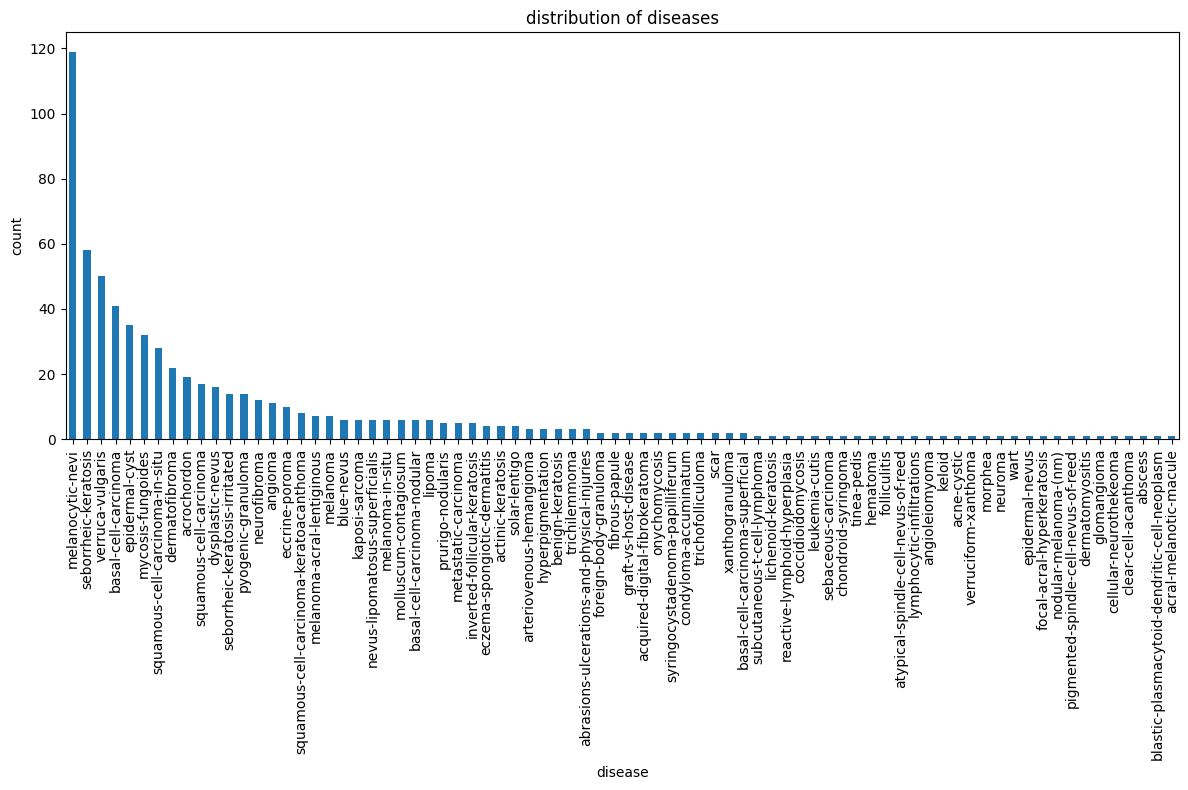

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

ddi_diseases_count = ddi_df['disease'].value_counts()

# total number of samples (rows in the original dataframe)
total_samples = ddi_df.shape[0]
print(f"total number of samples: {total_samples}")

# mean number of samples per disease
mean_samples_per_disease = ddi_diseases_count.mean()
print(f"mean samples per disease: {mean_samples_per_disease:.2f}")

# disease with most samples
most_samples_disease = ddi_diseases_count.idxmax()
most_samples_count = ddi_diseases_count.max()
print(f"disease with most samples: '{most_samples_disease}' with {most_samples_count} samples")

# disease with least samples
least_samples_disease = ddi_diseases_count.idxmin()
least_samples_count = ddi_diseases_count.min()
print(f"disease with least samples: '{least_samples_disease}' with {least_samples_count} samples")

# calculate quartiles for disease counts
q1 = ddi_diseases_count.quantile(0.25)
q2 = ddi_diseases_count.quantile(0.50) # median
q3 = ddi_diseases_count.quantile(0.75)

print(f"\nquartile values for disease counts:")
print(f"q1 (25th percentile): {q1}")
print(f"q2 (median/50th percentile): {q2}")
print(f"q3 (75th percentile): {q3}")

# number of diseases in each quartile
num_q1 = (ddi_diseases_count <= q1).sum()
num_q2 = ((ddi_diseases_count > q1) & (ddi_diseases_count <= q2)).sum()
num_q3 = ((ddi_diseases_count > q2) & (ddi_diseases_count <= q3)).sum()
num_q4 = (ddi_diseases_count > q3).sum()

print(f"\nnumber of diseases per quartile:")
print(f"diseases with <= q1 samples ({q1:.0f}): {num_q1}")
print(f"diseases with > q1 and <= q2 samples ({q1:.0f}-{q2:.0f}): {num_q2}")
print(f"diseases with > q2 and <= q3 samples ({q2:.0f}-{q3:.0f}): {num_q3}")
print(f"diseases with > q3 samples ({q3:.0f}+): {num_q4}")


# create a bar plot
plt.figure(figsize=(12, 8)) # make the figure a bit bigger so labels are readable
ddi_diseases_count.plot(kind='bar')
plt.title('distribution of diseases')
plt.xlabel('disease')
plt.ylabel('count')
plt.xticks(rotation=90) # rotate x-axis labels for better readability
plt.tight_layout() # adjust layout to prevent labels from being cut off

# save the plot to a file
# plt.savefig('disease_distribution.png')
# print("\nplot saved as disease_distribution.png")

In [4]:
# Load the dataset
dataset_path = 'data/dermavqa/data/reddit/df_mediqa-magic-final.csv'
dqa_df = pd.read_csv(dataset_path)

dqa_df

,image_id,author_role,anatomic_locations,sex,age_norm,skin_type,split,encounter_id
0,11mk4th,patient,eyeregion,M,21.0,IV,train,11mk4th
1,11k2tzj,patient,nose,NaN,NaN,III,valid,11k2tzj
2,125gfgg,patient,unidentifiable,NaN,NaN,III,train,125gfgg
3,ih99w9,patient,face,NaN,NaN,IV,train,ih99w9
4,11n62qx,patient,face,NaN,NaN,III,train,11n62qx
...,...,...,...,...,...,...,...,...
485,11nbyif,patient,unidentifiable,NaN,NaN,III,train,11nbyif
486,11tdh8d,patient,lowerleg,F,NaN,IV,train,11tdh8d
487,xq7o0p,patient,foot-sole,NaN,NaN,II,train,xq7o0p
488,11ivi7p,patient,arm|forearm,F,NaN,I,train,11ivi7p


In [6]:
# Load the dataset
dataset_path = 'data/dermavqa/data/reddit/train_answersonly.json'
dqa_df = pd.read_json(dataset_path)

print(dqa_df.columns)
# dqa_df
for key, value in dqa_df.head(10)['responses'].items():
    print(f"{key}: {value}\n")

Index(['encounter_id', 'image_ids', 'responses'], dtype='object')
0: [{'author_id': 'annotator1', 'content_en': 'Most probably it is a case of Milia. A milium is a small cyst containing keratin (the skin protein). Milia do not need to be treated unless they are a cause for concern for the patient. They often clear up by themselves within a few months. Where possible, further trauma should be minimized to reduce the development of new lesions. The lesion may be de-roofed using a sterile needle or blade and the contents squeezed or pricked out.\nThey may be destroyed using diathermy and curettage, or cryotherapy.', 'completeness': 1, 'contains_freq_ans': 1}]

1: [{'author_id': 'annotator1', 'content_en': 'Most probably this is a case of blind pimple. Blind pimples are pimples (zits) that form under your skin. They may stay under your skin’s surface, causing pain and inflammation. Or they may erupt through the surface in the form of a whitehead, blackhead, or red bump. Treatment includes 

In [8]:
len(dqa_df)

347

In [ ]:
# Load the dataset
dataset_path = 'data/dermavqa/data/iiyi/df_users_map.csv'
dqa_df = pd.read_csv(dataset_path)

dqa_df.head(1)

,user_page,author_id,validation_level,rank_level,username,rank,role,forum_role_title,title_next_leveling,badges
0,space-uid-950493.html,U00000,md1_validated,unk,争**医,48.0,NaN,皮肤及性传播疾病版主,NaN,"['金钻晋级', '蓝钻晋级', '晋级四级', '晋级二级', '持之以恒LV2', '人..."


In [35]:
# Load the dataset
dataset_path = 'data/dermavqa/data/iiyi/test_ht.json'
dqa_df = pd.read_json(dataset_path)


dqa_df.head(1)["responses"][0]

[{'author_id': 'U00151',
  'content_zh': '腿上毛囊炎，手上汗疱疹',
  'content_en': 'folliculitis in the leg; pompholyx in the palm.',
  'content_es': 'foliculitis en la pierna; dishidrosis en la palma de la mano.',
  'completeness': 1.0,
  'contains_freq_ans': 0.0},
 {'author_id': 'U00646',
  'content_zh': '手掌有点像梅毒疹。',
  'content_en': 'Looks like it is Syphilitic rash in the palm.',
  'content_es': 'Parece una erupción sifilítica en la palma de la mano.',
  'completeness': 1.0,
  'contains_freq_ans': 1.0},
 {'author_id': 'U01599',
  'content_zh': '问病史，不排除梅毒疹？？',
  'content_en': 'Check the medical history.  Would not exclude Syphilitic rash.',
  'content_es': 'Comprueba el historial médico.  No excluiría la erupción sifilítica.',
  'completeness': 1.0,
  'contains_freq_ans': 1.0},
 {'author_id': 'U00300',
  'content_zh': '手上像梅毒疹，',
  'content_en': 'Looks like it is Syphilitic rash in the palm.',
  'content_es': 'Parece que es una erupción sifilítica palmar.',
  'completeness': 1.0,
  'contains_fre

In [36]:
dqa_df.head(1)

,encounter_id,author_id,image_ids,query_title_zh,query_content_zh,query_title_en,query_content_en,query_title_es,query_content_es,responses
0,ENC00908,U13429,"[IMG_ENC00908_00001.jpg, IMG_ENC00908_00002.jpg]",看一下是皮肤病吗,图一：大腿外侧起了一圈小疙瘩，两个月左右图二：手掌起小红点，手掌感觉微麻,Take a look. Is this a skin disease?,"Picture 1: On the outside of the thigh, there...",Mirad. ¿Es una enfermedad de la piel?,"Foto 1: En la parte externa del muslo, hay un ...","[{'author_id': 'U00151', 'content_zh': '腿上毛囊炎，..."


In [3]:
# Load the dataset
dataset_path = 'data/fitzpatrick17k/fitzpatrick17k.csv'
fitz_df = pd.read_csv(dataset_path)

fitz_df.head(5)

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


In [ ]:
# Load the dataset
dataset_path = 'data/scin/dataset/scin_app_questions.csv'
scin_df = pd.read_csv(dataset_path)

scin_df.head(10)

,Column Name,Question Content,Comments
0,age_bucket,Age\nSmall text: Age influences risk of certai...,NaN
1,sex_at_birth,Sex at birth\nSmall text: Risk of diseases var...,NaN
2,skin_type,How does your skin react to sun exposure?\nSma...,NaN
3,race_ethnicity*,With which racial or ethnic groups do you iden...,NaN
4,textures*,Describe how the affected skin area feels\nSma...,NaN
5,body_parts*,Where on your body is the issue?\nSelect all t...,NaN
6,condition_symptoms*,Are you experiencing any of the following with...,NaN
7,other_symptoms*,Do you have any of these symptoms?\nSmall text...,NaN
8,related_category,Which most closely describes your skin issue?\...,NaN
9,condition_duration,For how long have you had this skin issue?\nOp...,NaN


In [7]:
# Load the dataset
dataset_path = 'data/scin/dataset/scin_cases.csv'
scin_df = pd.read_csv(dataset_path)

scin_df.head(10)

,case_id,source,release,year,age_group,sex_at_birth,fitzpatrick_skin_type,race_ethnicity_american_indian_or_alaska_native,race_ethnicity_asian,race_ethnicity_black_or_african_american,...,related_category,condition_duration,image_1_path,image_2_path,image_3_path,image_1_shot_type,image_2_shot_type,image_3_shot_type,combined_race,race_ethnicity_two_or_more_after_mitigation
0,-1000600354148496558,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,RASH,ONE_DAY,dataset/images/-3205742176803893704.png,NaN,NaN,CLOSE_UP,NaN,NaN,NaN,NaN
1,-1002039107727665188,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,NaN,NaN,dataset/images/-4762289084741430925.png,NaN,NaN,CLOSE_UP,NaN,NaN,NaN,NaN
2,-1003358831658393077,SCIN,1.0.0,2023,AGE_18_TO_29,MALE,NONE_IDENTIFIED,NaN,NaN,NaN,...,OTHER_ISSUE_DESCRIPTION,ONE_TO_FOUR_WEEKS,dataset/images/-4027806997035329030.png,NaN,NaN,CLOSE_UP,NaN,NaN,HISPANIC_LATINO_OR_SPANISH_ORIGIN,NaN
3,-1003826561155964328,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,OTHER_ISSUE_DESCRIPTION,ONE_DAY,dataset/images/-5332065579713135540.png,dataset/images/-6353431708064969797.png,dataset/images/742075435141960831.png,AT_DISTANCE,AT_AN_ANGLE,CLOSE_UP,NaN,NaN
4,-1003844406100696311,SCIN,1.0.0,2023,AGE_40_TO_49,FEMALE,FST3,NaN,NaN,NaN,...,RASH,ONE_DAY,dataset/images/-3799298995660217860.png,dataset/images/-5881426422999442186.png,dataset/images/5854025080806696361.png,AT_AN_ANGLE,AT_DISTANCE,CLOSE_UP,WHITE,NaN
5,-1005079160214352144,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,RASH,LESS_THAN_ONE_WEEK,dataset/images/-3575683440831198879.png,dataset/images/6164754101533643044.png,dataset/images/7125798012232703466.png,CLOSE_UP,AT_AN_ANGLE,AT_DISTANCE,NaN,NaN
6,-1010778459521153386,SCIN,1.0.0,2023,AGE_40_TO_49,FEMALE,FST1,NaN,NaN,NaN,...,RASH,LESS_THAN_ONE_WEEK,dataset/images/-6942912841265248602.png,dataset/images/-815168034213335912.png,dataset/images/8479707042238010445.png,AT_AN_ANGLE,AT_DISTANCE,CLOSE_UP,HISPANIC_LATINO_OR_SPANISH_ORIGIN,NaN
7,-1013831220015814987,SCIN,1.0.0,2023,AGE_UNKNOWN,MALE,FST4,NaN,NaN,NaN,...,RASH,ONE_TO_THREE_MONTHS,dataset/images/-220649468572111832.png,NaN,NaN,CLOSE_UP,NaN,NaN,WHITE,NaN
8,-101827005996397499,SCIN,1.0.0,2023,AGE_18_TO_29,MALE,FST2,NaN,NaN,NaN,...,RASH,ONE_TO_THREE_MONTHS,dataset/images/-217828380359571871.png,dataset/images/-4055728304670056584.png,NaN,CLOSE_UP,AT_AN_ANGLE,NaN,HISPANIC_LATINO_OR_SPANISH_ORIGIN,NaN
9,-1022162013984621110,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,NaN,NaN,dataset/images/8406712750126834903.png,NaN,NaN,CLOSE_UP,NaN,NaN,NaN,NaN


In [8]:
# Load the dataset
dataset_path = 'data/scin/dataset/scin_label_questions.csv'
scin_df = pd.read_csv(dataset_path)

scin_df.head(10)

,Related column family,Labeling Question Type,Question,Comments
0,dermatologist_gradable_for_skin_condition,RADIO,Is quality of the images sufficient for you to...,NaN
1,NaN,RADIO,Are you able to answer this question even if y...,"As of initial release, these question answers ..."
2,dermatologist_skin_condition_label,REPEATABLE,Please provide your top three differential dia...,NaN
3,dermatologist_skin_condition_label,AUTOCOMPLETE,Please provide up to 3 diagnoses for this case...,NaN
4,dermatologist_skin_condition_label,TEXT,"If the condition is not in the menu, please se...",NaN
5,dermatologist_skin_condition_confidence,RADIO,Please indicate how confident you are in this ...,These confidence values correspond to the 1-5 ...
6,dermatologist_gradable_for_fitzpatrick_skin_type,BOOLEAN,Are these gradable for skin type?,NaN
7,dermatologist_fitzpatrick_skin_type_label,RADIO,What skin type does this person have?\nAnswer ...,NaN
8,monk_skin_tone_label,RADIO,Which of the 10 skin tone categories best matc...,NaN
9,NaN,BOOLEAN,It was difficult to assess the skintone of thi...,NaN


In [9]:
# Load the dataset
dataset_path = 'data/scin/dataset/scin_labels.csv'
scin_df = pd.read_csv(dataset_path)

scin_df.head(10)

,case_id,dermatologist_gradable_for_skin_condition_1,dermatologist_gradable_for_skin_condition_2,dermatologist_gradable_for_skin_condition_3,dermatologist_skin_condition_on_label_name,dermatologist_skin_condition_confidence,weighted_skin_condition_label,dermatologist_gradable_for_fitzpatrick_skin_type_1,dermatologist_gradable_for_fitzpatrick_skin_type_2,dermatologist_gradable_for_fitzpatrick_skin_type_3,dermatologist_fitzpatrick_skin_type_label_1,dermatologist_fitzpatrick_skin_type_label_2,dermatologist_fitzpatrick_skin_type_label_3,gradable_for_monk_skin_tone_india,gradable_for_monk_skin_tone_us,monk_skin_tone_label_india,monk_skin_tone_label_us
0,-1000600354148496558,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Inflicted skin lesions', 'Eczema', 'Irritant...","[4, 4, 3]","{'Inflicted skin lesions': 0.41, 'Eczema': 0.4...",YES,NaN,NaN,FST2,NaN,NaN,True,True,2.0,1.0
1,-1002039107727665188,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Prurigo nodularis', 'Actinic Keratosis', 'SC...","[4, 3, 4]","{'Prurigo nodularis': 0.41, 'SCC/SCCIS': 0.41,...",YES,NaN,NaN,FST1,NaN,NaN,True,True,3.0,3.0
2,-1003358831658393077,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Impetigo', 'Herpes Zoster', 'Bullous dermati...","[2, 1, 1]","{'Impetigo': 0.55, 'Herpes Zoster': 0.23, 'Bul...",YES,NaN,NaN,FST4,NaN,NaN,True,True,3.0,4.0
3,-1003826561155964328,NO_IMAGE_QUALITY_INSUFFICIENT,NaN,NaN,[],[],{},NO,NaN,NaN,NaN,NaN,NaN,True,True,2.0,4.0
4,-1003844406100696311,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Lichen planus/lichenoid eruption', 'Follicul...","[1, 1, 1]","{'Lichen planus/lichenoid eruption': 0.33, 'Fo...",YES,NaN,NaN,FST1,NaN,NaN,True,True,1.0,1.0
5,-1005079160214352144,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Drug Rash', 'Viral Exanthem', 'Eczema']","[2, 2, 1]","{'Drug Rash': 0.41, 'Viral Exanthem': 0.41, 'E...",YES,NaN,NaN,FST3,NaN,NaN,True,True,2.0,2.0
6,-1010778459521153386,NO_IMAGE_QUALITY_INSUFFICIENT,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,"['Urticaria', 'Leukocytoclastic Vasculitis', '...","[4, 2, 5, 1, 1]","{'Urticaria': 0.6, 'Leukocytoclastic Vasculiti...",YES,YES,YES,FST4,FST3,FST4,True,True,3.0,3.0
7,-1013831220015814987,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Inflicted skin lesions', 'Basal Cell Carcino...","[2, 4, 1]","{'Basal Cell Carcinoma': 0.55, 'Inflicted skin...",YES,NaN,NaN,FST3,NaN,NaN,True,True,3.0,4.0
8,-101827005996397499,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,"['Psoriasis', 'Eczema', 'Eczema', 'Acute and c...","[1, 3, 3, 2, 4, 3]","{'Eczema': 0.67, 'Psoriasis': 0.11, 'Acute and...",YES,YES,YES,FST3,FST4,FST4,True,True,2.0,4.0
9,-1022162013984621110,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,['Purpura'],[3],{'Purpura': 1.0},YES,NaN,NaN,FST4,NaN,NaN,True,True,3.0,3.0


In [20]:
dataset = "data/skincap/skincap_v240623.csv"
skincap_df = pd.read_csv(dataset)
print(skincap_df.columns)
skincap_df.head(10)

Index(['id', 'skincap_file_path', 'ori_file_path', 'disease', 'caption_zh',
       'caption_zh_polish', 'caption_zh_polish_en', 'remark', 'source',
       'skin_tone', 'malignant', 'fitzpatrick_scale', 'fitzpatrick_centaur',
       'nine_partition_label', 'three_partition_label', 'url', 'Vesicle',
       'Papule', 'Macule', 'Plaque', 'Abscess', 'Pustule', 'Bulla', 'Patch',
       'Nodule', 'Ulcer', 'Crust', 'Erosion', 'Excoriation', 'Atrophy',
       'Exudate', 'Purpura/Petechiae', 'Fissure', 'Induration', 'Xerosis',
       'Telangiectasia', 'Scale', 'Scar', 'Friable', 'Sclerosis',
       'Pedunculated', 'Exophytic/Fungating', 'Warty/Papillomatous',
       'Dome-shaped', 'Flat topped', 'Brown(Hyperpigmentation)', 'Translucent',
       'White(Hypopigmentation)', 'Purple', 'Yellow', 'Black', 'Erythema',
       'Comedo', 'Lichenification', 'Blue', 'Umbilicated', 'Poikiloderma',
       'Salmon', 'Wheal', 'Acuminate', 'Burrow', 'Gray', 'Pigmented', 'Cyst',
       'Do not consider this image

,id,skincap_file_path,ori_file_path,disease,caption_zh,caption_zh_polish,caption_zh_polish_en,remark,source,skin_tone,...,Umbilicated,Poikiloderma,Salmon,Wheal,Acuminate,Burrow,Gray,Pigmented,Cyst,Do not consider this image
0,1,1.png,000002.png,melanoma-in-situ,发生于足心。可见形状不规则的褐色斑片。建议做病理/皮肤镜检查以明确诊断（色素痣/黑色素瘤）。,在足底出现了形状不规则的褐色斑块，这种情况可能是色素痣或黑色素瘤。建议进行病理学或皮肤镜检查...,Irregular brown patches are present on the sol...,NaN,ddi,56.0,...,0,0,0,0,0,0,0,0,0,0
1,2,2.png,000003.png,mycosis-fungoides,边界清晰的白色斑片。建议做Wood灯、皮肤镜或病理检查，明确是否为白癜风、贫血痣等疾病。,这种描述表明可能存在皮肤上的白色斑块，建议进行Wood灯检查、皮肤镜检查或病理检查，以明确诊...,This description suggests the presence of whit...,NaN,ddi,56.0,...,0,0,0,0,0,0,0,0,0,0
2,3,3.png,000004.png,squamous-cell-carcinoma-in-situ,形状不规范的黑色斑块，中央呈红色。建议做皮肤镜和/或病理学检查，明确是否为脂溢性角化症、基底...,该患者表现为形状不规则的黑色斑块，中央呈红色，需考虑脂溢性角化症、基底细胞癌或黑色素瘤等疾病...,The patient presents with irregularly shaped b...,NaN,ddi,56.0,...,0,0,0,0,0,0,0,0,0,0
3,4,4.png,000005.png,basal-cell-carcinoma,发生于面部。皮损由黑色丘疹和斑疹组成。建议做病理/皮肤镜检查以明确诊断（黑色素瘤）。,面部黑色丘疹和斑疹的皮损可能是黑色素瘤的表现，为了明确诊断建议进行病理学或皮肤镜检查。,The lesion on the face consisting of black pap...,NaN,ddi,12.0,...,0,0,0,0,0,0,0,0,0,0
4,5,5.png,000006.png,squamous-cell-carcinoma,发生于胫前皮肤溃疡。表现为黑色-黄色伤口；边缘轻度隆起。考虑皮肤软组织感染或皮肤肿瘤。,患者出现的症状与胫前皮肤溃疡有关，这种溃疡呈黑色-黄色，边缘轻度隆起，可能是皮肤软组织感染或...,The patient's symptoms are related to a shin s...,NaN,ddi,56.0,...,0,0,0,0,0,0,0,0,0,0
5,6,6.png,000007.png,melanoma-acral-lentiginous,发生于足底黑色斑点，边缘清晰，形状稍不对称。考虑色素痣。建议使用皮肤镜检查。,在足底出现的黑色斑点，边缘清晰，形状稍有不对称，考虑为色素痣。建议进行皮肤镜检查以确认诊断。,Black spots with clear edges and slightly asym...,NaN,ddi,56.0,...,0,0,0,0,0,0,0,0,0,0
6,7,7.png,000008.png,melanoma-in-situ,发生于甲边缘。为不规则黑色斑片。考虑黑色素瘤，建议做皮肤镜/病理检查。,患者皮肤上出现了发生于甲边缘的不规则黑色斑片，这种病灶可能是黑色素瘤。为了明确诊断，建议进行...,"In this case, there are irregular black patche...",NaN,ddi,56.0,...,0,0,0,0,0,0,0,0,0,1
7,8,8.png,000009.png,melanoma-acral-lentiginous,黑色方形斑片；边缘基本整齐。考虑黑色素瘤待查，建议做皮肤镜/病理检查。,黑色方形斑片，边缘基本整齐，可能是黑色素瘤。黑色素瘤是一种常见的皮肤恶性肿瘤，通常是由黑素细...,The black square patch with mostly regular edg...,NaN,ddi,56.0,...,0,0,0,0,0,0,0,0,0,0
8,9,9.png,000010.png,basal-cell-carcinoma-superficial,红色斑片，少许鳞屑。考虑炎症类皮肤改变。,这种病例表现为皮肤上出现红色斑片，伴有少量鳞屑，这种情况往往提示可能存在炎症性皮肤病变，如湿...,This presentation of red patches with slight s...,NaN,ddi,34.0,...,0,0,0,0,0,0,0,0,0,0
9,10,10.png,000011.png,squamous-cell-carcinoma,红色光滑的外生性结节，根部稍缩窄。考虑鳞癌待查,红色光滑的外生性结节，根部稍缩窄，可能是鳞癌的表现。鳞癌是一种常见的皮肤肿瘤，通常起源于表皮...,"The red, smooth, exophytic nodule with a sligh...",NaN,ddi,56.0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("joshuachou/SkinCAP")
ds

Resolving data files:   0%|          | 0/4347 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 4346
    })
})

In [13]:
pd_skin = ds['train'].to_pandas()

Total number of samples: 16577
Mean samples per label: 145.41
Label with most samples: 'psoriasis' with 653 samples
Label with least samples: 'xanthomas' with 53 samples

Quartile values for label counts:
Q1 (25th percentile): 73.0
Q2 (median/50th percentile): 102.0
Q3 (75th percentile): 163.5

Number of labels per quartile:
Labels with <= Q1 samples (73): 31
Labels with > Q1 and <= Q2 samples (73-102): 27
Labels with > Q2 and <= Q3 samples (102-164): 27
Labels with > Q3 samples (164+): 29

--- Label distribution table ---
label
psoriasis                                                653
squamous cell carcinoma                                  581
lichen planus                                            491
basal cell carcinoma                                     468
allergic contact dermatitis                              430
lupus erythematosus                                      410
neutrophilic dermatoses                                  361
sarcoidosis                           

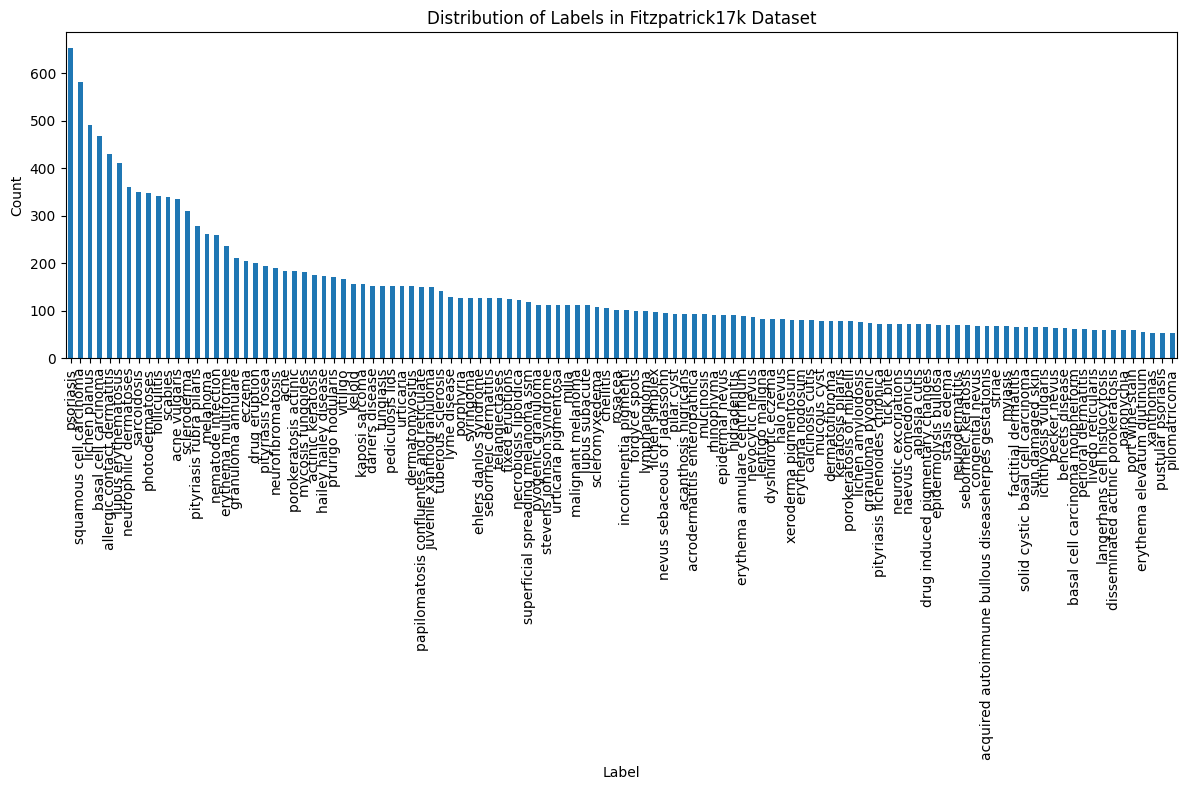

In [4]:
# Analysis of Fitzpatrick17k dataset - Label column
import pandas as pd
import matplotlib.pyplot as plt

# Count the occurrences of each label
fitz_label_counts = fitz_df['label'].value_counts()

# --- statistical analysis ---

# Total number of samples (rows in the original dataframe)
total_samples_fitz = fitz_df.shape[0]
print(f"Total number of samples: {total_samples_fitz}")

# Mean number of samples per label
mean_samples_per_label = fitz_label_counts.mean()
print(f"Mean samples per label: {mean_samples_per_label:.2f}")

# Label with most samples
most_samples_label = fitz_label_counts.idxmax()
most_samples_count = fitz_label_counts.max()
print(f"Label with most samples: '{most_samples_label}' with {most_samples_count} samples")

# Label with least samples
least_samples_label = fitz_label_counts.idxmin()
least_samples_count = fitz_label_counts.min()
print(f"Label with least samples: '{least_samples_label}' with {least_samples_count} samples")

# Calculate quartiles for label counts
q1_fitz = fitz_label_counts.quantile(0.25)
q2_fitz = fitz_label_counts.quantile(0.50) # median
q3_fitz = fitz_label_counts.quantile(0.75)

print(f"\nQuartile values for label counts:")
print(f"Q1 (25th percentile): {q1_fitz}")
print(f"Q2 (median/50th percentile): {q2_fitz}")
print(f"Q3 (75th percentile): {q3_fitz}")

# Number of labels in each quartile
num_q1_fitz = (fitz_label_counts <= q1_fitz).sum()
num_q2_fitz = ((fitz_label_counts > q1_fitz) & (fitz_label_counts <= q2_fitz)).sum()
num_q3_fitz = ((fitz_label_counts > q2_fitz) & (fitz_label_counts <= q3_fitz)).sum()
num_q4_fitz = (fitz_label_counts > q3_fitz).sum()

print(f"\nNumber of labels per quartile:")
print(f"Labels with <= Q1 samples ({q1_fitz:.0f}): {num_q1_fitz}")
print(f"Labels with > Q1 and <= Q2 samples ({q1_fitz:.0f}-{q2_fitz:.0f}): {num_q2_fitz}")
print(f"Labels with > Q2 and <= Q3 samples ({q2_fitz:.0f}-{q3_fitz:.0f}): {num_q3_fitz}")
print(f"Labels with > Q3 samples ({q3_fitz:.0f}+): {num_q4_fitz}")

# --- Label distribution table and plot ---
print("\n--- Label distribution table ---")
print(fitz_label_counts.to_string())

plt.figure(figsize=(12, 8))
fitz_label_counts.plot(kind='bar')
plt.title('Distribution of Labels in Fitzpatrick17k Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('fitzpatrick_label_distribution.png')
print("\nPlot saved as fitzpatrick_label_distribution.png")



--- Cumulative percentage of samples by label (top 10) ---
label
psoriasis                       3.939193
squamous cell carcinoma         7.444049
lichen planus                  10.405984
basal cell carcinoma           13.229173
allergic contact dermatitis    15.823128
lupus erythematosus            18.296435
neutrophilic dermatoses        20.474151
sarcoidosis                    22.579478
photodermatoses                24.678772
folliculitis                   26.741871



Cumulative plot saved as cumulative_fitzpatrick_label_distribution.png


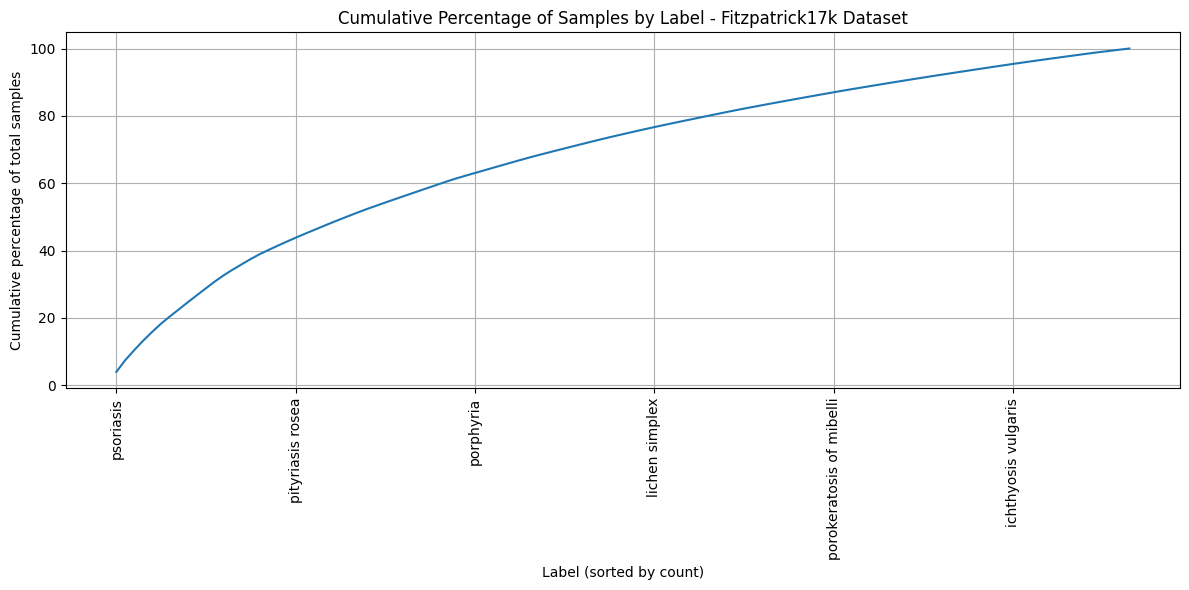

In [5]:
# --- Cumulative distribution analysis for Fitzpatrick17k ---
cumulative_counts_fitz = fitz_label_counts.sort_values(ascending=False).cumsum()
percentage_cumulative_fitz = (cumulative_counts_fitz / total_samples_fitz) * 100

print("\n--- Cumulative percentage of samples by label (top 10) ---")
print(percentage_cumulative_fitz.head(10).to_string())

# Plot cumulative distribution
plt.figure(figsize=(12, 6))
percentage_cumulative_fitz.plot()
plt.title('Cumulative Percentage of Samples by Label - Fitzpatrick17k Dataset')
plt.xlabel('Label (sorted by count)')
plt.ylabel('Cumulative percentage of total samples')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.savefig('cumulative_fitzpatrick_label_distribution.png')
print("\nCumulative plot saved as cumulative_fitzpatrick_label_distribution.png")
